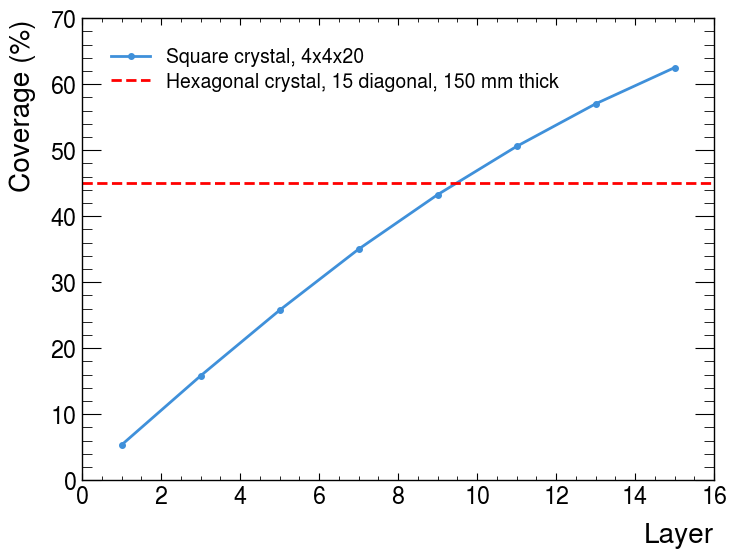

In [17]:

import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
import mplhep as mpl

mpl.style.use('ATLAS')

files=[]
for i in range(1,8+1):
    filename="Squarecoordinates_thickness"+str(i)+"_solidangle.root"
    files.append(filename)
layers=[1,3,5,7,9,11,13,15]
efficiencys=[]
for file_ in files:
    # Load the original ROOT file
    with uproot.open(file_) as file:
        # Extract relevant NTuples
        count = file["Counter"].arrays(library="pd")["EventID"]
    efficiencys.append(len(count)/1000000*100)

plt.plot(layers,efficiencys,".-",label="Square crystal, 4x4x20")
plt.hlines(45.0566,0,16,"r","dashed",label="Hexagonal crystal, 15 diagonal, 150 mm thick")
plt.xlabel("Layer")
plt.ylabel("Coverage (%)")
plt.legend()

In [4]:
import uproot
import pandas as pd
import numpy as np
import math  # For atan2, pi

# Function to load a .dat file and create a weight getter
def create_weight_func(dat_file):
    if not dat_file: return lambda val: 1.0  # Uniform if no file
    data = np.loadtxt(dat_file, unpack=True)  # upper_edges, weights
    upper_edges = data[0]
    weights = data[1]
    bin_widths = np.diff(np.append(0, upper_edges))
    total_integral = np.sum(weights * bin_widths)
    
    def get_weight(val):
        if val < 0 or val > upper_edges[-1]:
            return 0
        bin_idx = np.searchsorted(upper_edges, val, side='right') - 1
        return weights[max(0, bin_idx)] / total_integral  # Normalized, constant per bin
    
    return get_weight

# Load weight functions (adjust paths/filenames; set to None if not using)
w_z = create_weight_func('biasz.dat')
w_phi = create_weight_func('biaspp.dat')  # Assuming phi (azimuthal)
w_rho = create_weight_func('biaspt.dat')   # Assuming pt (transverse rho)

# Uniform densities (adjust ranges based on your simulation; e.g., z in cm)
max_z = 10.0  # Example: if uniform from 0 to 10 cm
p_uniform_z = 1 / max_z
max_phi = 2 * math.pi  # 0 to 2pi
p_uniform_phi = 1 / max_phi
max_rho = 5.0  # Example max transverse; adjust to your volume
p_uniform_rho = 1 / max_rho  # Simplified; for cylindrical, it's more complex (2pi rho dr), but if biases independent, adjust accordingly

total_sim_events = 100000  # From your code; unused in weighted eff, but for reference

for file_ in files:
    with uproot.open(file_) as file:
        edep_tree = file["EdepCounter"]
        truth_gamma_tree = file["TruthGamma"]
        truth_ps_tree = file["TruthPs"]
        truth_positron_tree = file["TruthPositron"]
        edep_df = edep_tree.arrays(library="pd")
        truth_gamma_df = truth_gamma_tree.arrays(library="pd")
        truth_ps_df = truth_ps_tree.arrays(library="pd")
        truth_positron_df = truth_positron_tree.arrays(library="pd")

    # Get positions per EventID (assume in truth_ps_df; take first if multiple)
    ps_grouped = truth_ps_df.groupby('EventID').agg({
        'PosZ_mm': 'first',  # Or 'mean'
        'PosX_mm': 'first',  # Add for rho, phi
        'PosY_mm': 'first'
    }).reset_index()

    # Compute rho and phi (in same units as .dat; assume mm, convert if needed)
    ps_grouped['rho'] = np.sqrt(ps_grouped['PosX_mm']**2 + ps_grouped['PosY_mm']**2) / 10  # mm to cm if needed
    ps_grouped['phi'] = np.arctan2(ps_grouped['PosY_mm'], ps_grouped['PosX_mm']) + math.pi  # To 0-2pi

    o_ps_ids = truth_ps_df[truth_ps_df['Type'] == 'o-Ps']['TrackID'].unique()
    p_ps_ids = truth_ps_df[truth_ps_df['Type'] == 'p-Ps']['TrackID'].unique()

    truth_gamma_ops_df = truth_gamma_df[truth_gamma_df['ParentID'].isin(o_ps_ids)]
    truth_gamma_pps_df = truth_gamma_df[truth_gamma_df['ParentID'].isin(p_ps_ids)]
    truth_gamma_others_df = truth_gamma_df[~(truth_gamma_df['ParentID'].isin(o_ps_ids) | truth_gamma_df['ParentID'].isin(p_ps_ids))]

    edep_grouped = edep_df.groupby(['EventID', 'DetectorName', 'FirstTime_ns'])['Edep_MeV'].sum().reset_index()
    edep_df_new = pd.DataFrame({
        "EventID": edep_grouped['EventID'].values,
        "DetectorName": edep_grouped['DetectorName'].values,
        "Edep_MeV": edep_grouped['Edep_MeV'].values,
        "FirstTime_ns": edep_grouped['FirstTime_ns'].values
    })

    common_events = edep_df_new.groupby("EventID").filter(lambda x: len(x) == 3)
    common_events['Max_Edep'] = common_events.groupby('EventID')['Edep_MeV'].transform('max')
    common_events['Total_Edep'] = common_events.groupby('EventID')['Edep_MeV'].transform('sum')
    common_events["Remaining_Sum"] = common_events['Total_Edep'] - common_events['Max_Edep']

    # Merge positions into common_events
    common_events = common_events.merge(ps_grouped, on='EventID', how='left')

    # Compute reweight per event (product of individual reweights)
    common_events['reweight_z'] = common_events['PosZ_mm'].apply(lambda z: w_z(z / 10) / p_uniform_z)  # mm to cm if needed
    common_events['reweight_phi'] = common_events['phi'].apply(lambda p: w_phi(p) / p_uniform_phi)
    common_events['reweight_rho'] = common_events['rho'].apply(lambda r: w_rho(r) / p_uniform_rho)
    common_events['reweight'] = common_events['reweight_z'] * common_events['reweight_phi'] * common_events['reweight_rho']

    # Group to event-level for efficiency
    event_level = common_events.groupby('EventID').first()  # Totals/reweights same per group

    detected = event_level['Total_Edep'].between(1, 1.3)
    weighted_detected = np.sum(event_level['reweight'][detected])
    total_weighted = 100000#np.sum(event_level['reweight'])
    efficiency = weighted_detected / total_weighted if total_weighted > 0 else 0

    print(f"File={file_}")
    print(f"o-Ps, detection efficiency={efficiency}")

FileNotFoundError: biasz.dat not found.